In [3]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.optimize import curve_fit



# Deposition #10

Slope: 0.730   mugm/h, Intercept: -0.010 mugm


Text(0, 0.5, 'QCM Reading ($\\mu g m $)')

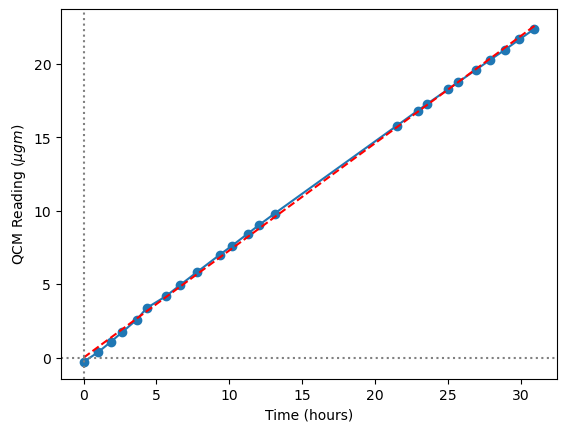

In [6]:
time = [ "2026-02-03 10:15",  "2026-02-03 11:15",  "2026-02-03 12:07", "2026-02-03 12:54", 
        "2026-02-03 13:53", "2026-02-03 14:35", "2026-02-03 15:53","2026-02-03 16:53", 
        "2026-02-03 18:00", "2026-02-03 19:35","2026-02-03 20:26","2026-02-03 21:31",
        "2026-02-03 22:17","2026-02-03 23:21","2026-02-04 07:45","2026-02-04 09:10",
        "2026-02-04 09:50", "2026-02-04 11:15", "2026-02-04 11:58", "2026-02-04 13:09",
        "2026-02-04 14:09", "2026-02-04 15:09", "2026-02-04 16:09", "2026-02-04 17:11"] # Example time points
QCM_readings = [-0.300, 0.365, 1.065, 1.726, 2.564, 3.375, 4.165, 4.944, 5.795,6.990,
                 7.613, 8.436, 9.018, 9.801, 15.79,16.81, 17.28, 18.26, 18.76,19.58,
                 20.27,20.95, 21.66, 22.38]  # Example QCM readings in Hz

#calculate slope
QCM_readings = np.array(QCM_readings)
time_dt = np.array([datetime.strptime(t, "%Y-%m-%d %H:%M") for t in time])
time_seconds = np.array([(t - time_dt[0]).total_seconds() for t in time_dt])
slope, intercept = np.polyfit(time_seconds/3600, QCM_readings, 1)
print(f"Slope: {slope:.3f}   mugm/h, Intercept: {intercept:.3f} mugm")

# Plotting
plt.plot(time_seconds/3600, QCM_readings, marker='o')
plt.plot(time_seconds/3600, slope * (time_seconds/3600) + intercept, linestyle='--', color='red')
plt.axhline(y=intercept, color='gray', linestyle=':')
plt.axvline(x=0, color='gray', linestyle=':')
plt.xlabel('Time (hours)')
plt.ylabel('QCM Reading ($\mu g m $)')

Saturation level A=127.8μg, 
Timescale τ=158.8h
Offset=-0.3μg
Target 25.0μg at 35.1h (02-04 21:18)


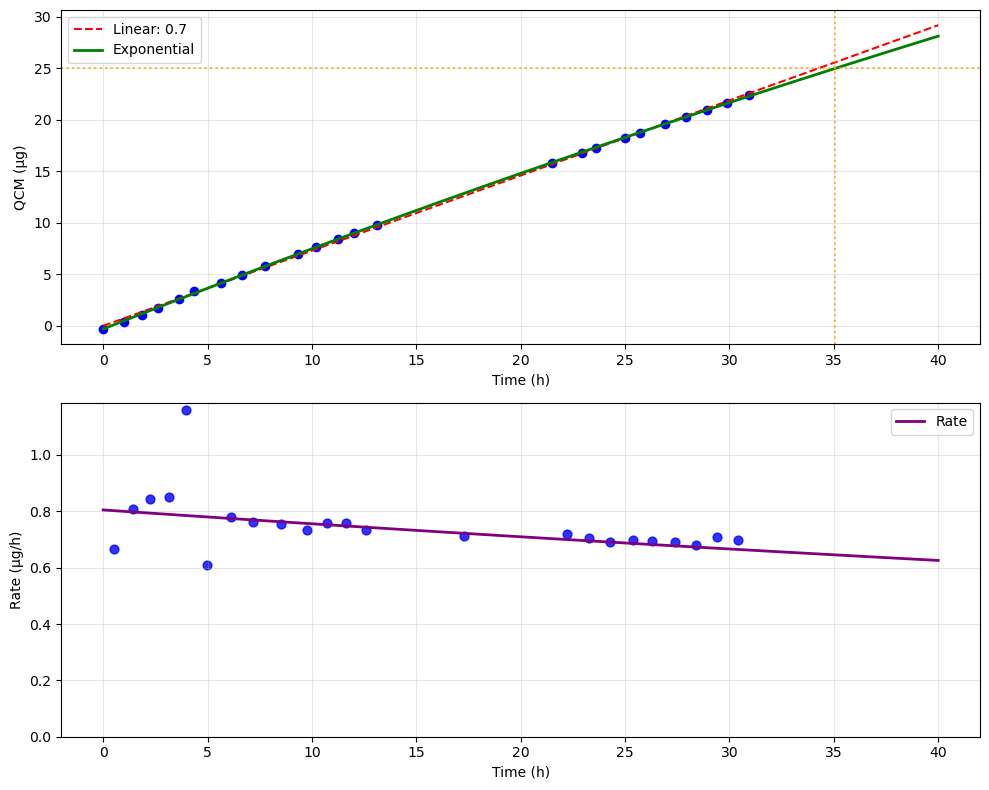

In [17]:




def exp_saturation_func(x, A, tau, offset):
    return A * (1 - np.exp(-x / tau)) + offset

# Fit and calculate parameters
A_exp, tau_exp, offset_exp = curve_fit(exp_saturation_func, time_seconds/3600, QCM_readings, p0=[20, 10, 0])[0]
time_fine = np.linspace(0, 40, 100)
derivative = (A_exp / tau_exp) * np.exp(-time_fine / tau_exp)

# Target calculation
target_value = 25.0
time_to_target = -tau_exp * np.log(1 - (target_value - offset_exp) / A_exp)
target_datetime = time_dt[0] + timedelta(hours=time_to_target)

print(f"Saturation level A={A_exp:.1f}μg, ") 
print(f"Timescale τ={tau_exp:.1f}h")
print(f"Offset={offset_exp:.1f}μg")
print(f"Target {target_value}μg at {time_to_target:.1f}h ({target_datetime.strftime('%m-%d %H:%M')})")

# Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(time_seconds/3600, QCM_readings, 'bo', markersize=6)
ax1.plot(time_fine, slope * (time_fine) + intercept, '--r', label=f'Linear: {slope:.1f}')
ax1.plot(time_fine, exp_saturation_func(time_fine, A_exp, tau_exp, offset_exp), '-g', linewidth=2, label='Exponential')
ax1.axhline(y=target_value, color='orange', linestyle=':', alpha=0.8)
ax1.axvline(x=time_to_target, color='orange', linestyle=':', alpha=0.8)
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('QCM (μg)')
ax1.legend()
ax1.grid(alpha=0.3)
#ax1.set_yscale('log')
#ax1.set_xscale('log')


rates = [(QCM_readings[i+1]-QCM_readings[i])/((time_seconds[i+1]-time_seconds[i])/3600) for i in range(len(QCM_readings)-1)]
rate_times = [(time_seconds[i+1]+time_seconds[i])/(2*3600) for i in range(len(QCM_readings)-1)]
ax2.plot(time_fine, derivative, '-', color='purple', linewidth=2, label='Rate')
ax2.scatter(rate_times, rates, color='blue', s=40, alpha=0.8)

ax2.set_xlabel('Time (h)')
ax2.set_ylabel('Rate (μg/h)')
plt.ylim(0,None)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

\
